In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [5]:
df=pd.read_csv("loan_logistic_project1.csv")
df

,Customer_ID,Age,Gender,Annual_Income,Credit_Score,Employment_Status,Loan_Amount,Loan_Term_Months,Interest_Rate,Previous_Default,Region,Loan_Approval
0,CUST10000,40.0,Male,77496.603094,735.849065,Employed,290975.576152,36.0,10.048692,No,Rural,1
1,CUST10001,33.0,F,30017.345630,549.846426,Employed,517614.966881,NaN,8.589697,No,urban,0
2,CUST10002,NaN,Female,74191.232325,683.184403,Unemployed,87996.219510,36.0,12.713673,No,Rural,1
3,CUST10003,53.0,Male,12499.337309,719.083550,EMP,240484.449235,48.0,15.171931,No,Urban,0
4,CUST10004,32.0,Male,80637.700421,NaN,Employed,136320.294324,48.0,12.410041,No,Semi-Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,CUST11495,59.0,NaN,-31828.332863,700.915845,Self-Employed,68760.819756,36.0,8.765064,No,Urban,0
1496,CUST11496,59.0,M,43578.703372,625.858091,Self-Employed,346711.696839,36.0,8.481175,No,Semi-Urban,0
1497,CUST11497,49.0,Female,36848.650977,812.911449,Employed,233330.624060,24.0,8.971788,No,Semi-Urban,1
1498,CUST11498,47.0,M,NaN,686.091154,Employed,146967.164228,24.0,9.284214,Yes,Urban,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        1500 non-null   object 
 1   Age                1425 non-null   float64
 2   Gender             1422 non-null   object 
 3   Annual_Income      1425 non-null   float64
 4   Credit_Score       1425 non-null   float64
 5   Employment_Status  1371 non-null   object 
 6   Loan_Amount        1425 non-null   float64
 7   Loan_Term_Months   1430 non-null   float64
 8   Interest_Rate      1425 non-null   float64
 9   Previous_Default   1428 non-null   object 
 10  Region             1430 non-null   object 
 11  Loan_Approval      1500 non-null   int64  
dtypes: float64(6), int64(1), object(5)
memory usage: 140.8+ KB


In [7]:
df.describe()

,Age,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Loan_Approval
count,1425.000000,1425.000000,1425.000000,1.425000e+03,1430.000000,1425.000000,1500.000000
mean,35.097544,69084.511023,676.949397,2.141986e+05,35.261538,10.851499,0.500000
std,11.858762,45283.437138,68.919059,1.416050e+05,14.931900,2.887934,0.500167
min,-3.000000,-31828.332863,457.630733,-1.452990e+05,12.000000,-0.767201,0.000000
25%,27.000000,47381.789110,631.976517,1.382115e+05,24.000000,8.910617,0.000000
50%,35.000000,64722.699901,678.560761,2.013525e+05,36.000000,10.875527,0.500000
75%,43.000000,82318.068878,725.220433,2.695563e+05,48.000000,12.774713,1.000000
max,81.000000,608931.218178,897.903714,1.805195e+06,60.000000,19.742328,1.000000


In [6]:
df.isnull().sum()

Customer_ID            0
Age                   75
Gender                78
Annual_Income         75
Credit_Score          75
Employment_Status    129
Loan_Amount           75
Loan_Term_Months      70
Interest_Rate         75
Previous_Default      72
Region                70
Loan_Approval          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
#Drop unnecessary columns
cols_to_drop = ['Customer_ID','Interest_Rate','Loan_Term_Months','Region']

df = df.drop(columns=cols_to_drop)

In [9]:
df.head()

,Age,Gender,Annual_Income,Credit_Score,Employment_Status,Loan_Amount,Previous_Default,Loan_Approval
0,40.0,Male,77496.603094,735.849065,Employed,290975.576152,No,1
1,33.0,F,30017.345630,549.846426,Employed,517614.966881,No,0
2,NaN,Female,74191.232325,683.184403,Unemployed,87996.219510,No,1
3,53.0,Male,12499.337309,719.083550,EMP,240484.449235,No,0
4,32.0,Male,80637.700421,NaN,Employed,136320.294324,No,1


In [10]:
df.dtypes

Age                  float64
Gender                object
Annual_Income        float64
Credit_Score         float64
Employment_Status     object
Loan_Amount          float64
Previous_Default      object
Loan_Approval          int64
dtype: object

In [11]:
#Separate Numerical & Categorical Columns for handeling missing/null values
num_cols = ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount']   #numerical column
cat_cols = ['Gender', 'Employment_Status', 'Previous_Default']      #categorical columns

In [12]:
#Handle Missing Values
#Numerical Columns - MEDIAN
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\prathamesh\AppData\Local\Temp\ipykernel_24364\3609127933.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [13]:
#Categorical Columns - MODE
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\prathamesh\AppData\Local\Temp\ipykernel_24364\2928296602.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df.isnull().sum()


Age                  0
Gender               0
Annual_Income        0
Credit_Score         0
Employment_Status    0
Loan_Amount          0
Previous_Default     0
Loan_Approval        0
dtype: int64

In [15]:
#Fix Inconsistent Values-because in our data column has various names
df['Gender'] = df['Gender'].replace({'M':'Male', 'F':'Female'})    #gender
df['Employment_Status'] = df['Employment_Status'].replace({'EMP':'Employed'})   #employee_status
df['Previous_Default'] = df['Previous_Default'].replace({'Y':'Yes', 'N':'No'})  #Previous_Default

In [16]:
#Convert Categorical - 0/1 (one_hot encoding)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [17]:
df.dtypes

Age                                float64
Annual_Income                      float64
Credit_Score                       float64
Loan_Amount                        float64
Loan_Approval                        int64
Gender_Male                           bool
Gender_Unknown                        bool
Employment_Status_Self-Employed       bool
Employment_Status_Unemployed          bool
Previous_Default_Yes                  bool
dtype: object

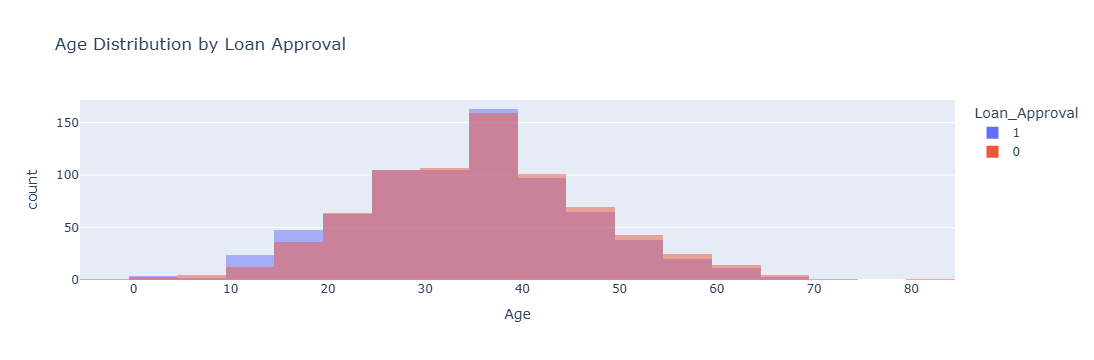

In [18]:
#Visualization
import plotly.express as px
fig = px.histogram(
    df,
    x='Age',
    color='Loan_Approval',
    nbins=30,
    title='Age Distribution by Loan Approval',
    barmode='overlay'
)
fig.show()

In [18]:
fig = px.box(
    df,
    x='Loan_Approval',
    y='Annual_Income',
    title='Annual Income vs Loan Approval'
)
fig.show()


In [19]:
fig = px.box(
    df,
    x='Loan_Approval',
    y='Credit_Score',
    title='Credit Score vs Loan Approval'
)
fig.show()


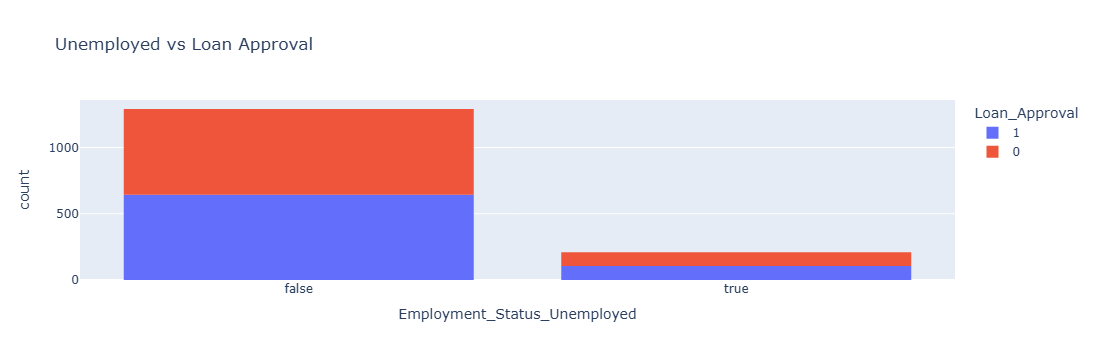

In [19]:
fig = px.histogram(
    df,
    x='Employment_Status_Unemployed',
    color='Loan_Approval',
    title='Unemployed vs Loan Approval'
)
fig.show()



In [20]:
#Separate features and target
X = df.drop('Loan_Approval', axis=1)   #feature
y = df['Loan_Approval']                #target

In [21]:
#Train–Test Split
#Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)    #stratify=y- keeps class balance


In [23]:
#Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\prathamesh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
y_pred_lr = model.predict(X_test)

In [25]:
#Logistic accuracy
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       150
           1       1.00      0.98      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [26]:
##Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
y_pred_dt = dt_model.predict(X_test)

In [28]:
#DecisionTree accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8533333333333334
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       150
           1       0.85      0.86      0.85       150

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



In [29]:
##Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_rf = rf.predict(X_test)

In [31]:
##Random Forest accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9366666666666666
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       150
           1       0.95      0.93      0.94       150

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



In [32]:
#Model Comparison
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.990000
1,Decision Tree,0.853333
2,Random Forest,0.936667


In [22]:
#gradient boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
gb = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=2
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9233333333333333


In [36]:
#XGBOOST
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=2
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9333333333333333
